In [1]:
import sklearn
import numpy
import pandas
import sklearn.datasets
import sklearn.preprocessing
import helpers
import os
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

Problem Analysis:
- Classification task, classify handwritten number digits
- Labels are given (supervised training)
- Values are scaled (no need to regularize)


**Data Inspection**

In [ ]:
MNIST = sklearn.datasets.fetch_openml("mnist_784")
X, Y = MNIST["data"], MNIST["target"]
X

**Visualizing instances of MNIST**

In [ ]:
single_data = numpy.array(X.iloc[11])
single_data_reshaped = single_data.reshape(28,28)
plt.imshow(single_data_reshaped, cmap="binary", interpolation="nearest")
plt.axis("off")
plt.show()

In [ ]:
# Label check on X[2522]
Y[11]

**Split data into test / train**

In [ ]:
X_train, X_test, Y_train, Y_test = X[:60000], X[60000:], Y[:60000], Y[60000:]
shuffle = numpy.random.permutation(60000)
X_train, Y_train = X_train.iloc[shuffle], Y_train.iloc[shuffle]

**Exploring Binary Classifiers : Stochastic Gradient Descent**

In [ ]:
import sklearn.linear_model

# Classifiers recognizing the digit 7

y_train_5 = ([int(y) == 5 for y in Y_train])
y_test_5 = ([int(y) == 5 for y in Y_test])

sgd_clf = sklearn.linear_model.SGDClassifier(random_state=42)

# Fits X_train with 2 unique classes (True, False)
sgd_clf.fit(X_train, y_train_5)

**Testing prediction using the trained model**

In [ ]:
sgd_clf.predict([single_data])

**Measuring Performance**

In [ ]:
# Cross-validation method K-fold, k = 3, measuring score (accuracy) (ratio of correct prediction)
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

Note that accuracy is not desirable, because we can hard code the classifier 
in ways to 'masks' the poor performance & bad algorithm that doesnt generalize the underlying pattern

**Confusion matrix**: Consider the misclassified instances as well as correctly classified instances
- Take in all False / True + Negative / Positive cases  
[[true negative,     false positive],  
[false negative,    true positive]]  

true negative: Correctly classified as (negative) ==> classify (not-5 object, not 5)  
false positive: Incorrectly classified as (positive) ==> classify (not-5 object, 5)  
false negative: Incorrectly classified as (negative) ==> classify (5 object, not 5)  
true positive: Correctly classified as (positive) ==> classify (5 object, 5)  

In [ ]:
# Performance measurement using Confusion Matrix, return predictions 
# | Fold 1 | Fold 2 | Fold 3 |
# Each iteration trains on 2 folds and test against remaining fold. ==> Each fold's act as a test set against the other 2 folds,
# ensuring every points in training set gets a prediction as if it were in a test set

from sklearn.model_selection import cross_val_predict
y_train_prediction = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5, y_train_prediction)

Precision: ratio of true positives / (true positives + false positives) => Accuracy of positive predictions  
Recall: ratio of true positives / (true positives + false negatives) => True-positive rate

Tradeoff (depends on classification task, whether we want more precision or more recall based on thresholds):   
When we INCREASE threshold, **increases precision but decreases recall**   
When we DECREASE threshold, **decrease precision but increases recall**  

Can plot a precision - recall graph to see at what point does the precision starts to fall sharply, and choose appropriate threshold score that produces higher
precision than the drop-off range

Use cases:
- High precision (*Of all the predicted positive cases, how many actually are correct?*): Important when false positives are costly (Email incorrectly classified as spam, medical tests incorrectly diagnose patients as positive for some diseases)
- High recall (*Of all the actual positive cases, how many of them were actually predicted as positives?*): Important for when false negatives are costly (Failing to detect fraud, failing to diagnose illnesses when theyre present, failing to detect anomalies)  

Analogies:
- Precision: When a model labels an email as spam, how likely is it that its actually spam?
- Recall: How many actual spam emails is the model actually able to detect (given an X number of spam emails)?

In [ ]:
from sklearn.metrics import precision_score, recall_score
print(precision_score(y_train_5, y_train_prediction))  # When prediction is 5, it is only correct 75% of the time
print(recall_score(y_train_5, y_train_prediction))     # Predicts 5s correctly 82% of the time

F1-score : Harmonic mean of precision and recall  
Higher score happens only when both recall score and precision score is high
TP / (TP + (FN+FP) / 2)

In [ ]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_prediction)

ROC - Curve: Receiver Operating Characteristics  
Plots *recall* against false positive rate  

In [ ]:
# Obtain the raw score of each predictions (distance of a sample from decision boundary)
# Decision boundary by default is 0
# If raw score > 0 then classified as positive prediction, otherwise a negative prediction
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")
y_scores

Decision Boundary Threshold:  
- An array contains decision boundaries sorted from largest to lowest
  - Lowering threshold increases recall but decrease precision

Thresholds are computed by:
1. Obtaining raw scores of predictions *y_scores*
2. Sort unique predictions in descending order
3. Use each score as a threshold (to make decision_boundary used to classify the rest of scores) and compute corresponding TPR and FPR

threshold: array of threshold scores in descending order
fpr array: holds the FPR at each threshold score
tpr array: holds the TPR at each threshold score

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

plt.plot(fpr, tpr, linewidth=2, label=None)
plt.plot([0, 1], [0, 1], 'k--')
plt.axis([0, 1, 0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

Middle line is the ROC curve of a purely random classifier, a good model would aim to steer clear away from this line toward the top-left corner   
Notice the area where the curve 'curves sharply', area where TPR is ~ 85% and FPR ~ 10%, is roughly where the tradeoff starts to appear exponentially  
If we try to tune the model further to improve TPR (recall), we also run into the area where FPR is also increasing, dropping the accuracy of the model significantly   

# Multiclass Classification

One-versus-all method: Train many binary (true/false) classifiers, each attempting to see whether the input belongs to the class it trained on. Take the decision score from each classifier given the same input and select the label that gets the highest score (typically preferred for binary classification algorithms)

One-versus-one: Train binary classifiers to recognize a pair of labels, and give them all the same inputs. The label that wins the most battles is the generalized response of the model

In [ ]:
# Training SGD_classification to handle multiclasses, this tells Sklearn to create many binary classifiers under the hood (OvA method), each trying to see if an output
# is label1 or not, label2 or not and so on.
sgd_clf.fit(X_train, Y_train)

In [ ]:
sgd_clf.predict([single_data])

In [ ]:
# Shows the raw score of each binary classifier under the hood. Positive scores correspond to the respective classifiers positively 
# recognizes the data as 'maybe' belonging to said classifier's respective label. The larger the score, the more 'confident' the 
sgd_clf.decision_function([single_data])

Different classifier model (RandomForest)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rndForest_clf = RandomForestClassifier(random_state=42)
rndForest_clf.fit(X_train, Y_train)

In [ ]:
rndForest_clf.predict([single_data])

In [ ]:
# Show the list of probability of each labels. Generalize the data with the label that has the highest probability
# Probability of a point generalized with a label represents the ratio of the hidden trees agreeing on said label (higher probability ==> more trees agree on this value)

rndForest_clf.predict_proba([single_data])

In [ ]:
cross_val_score(sgd_clf, X_train,Y_train, cv=3, scoring="accuracy")

**Error Analysis**

In [ ]:
# Confusion Matrix
y_train_prediction = cross_val_predict(sgd_clf, X_train, Y_train, cv=3)

In [ ]:
conf_mx = confusion_matrix(Y_train, y_train_prediction)
conf_mx

Visualizing the confusion matrix helps recognizing where the error may be.  
Diagonal represents the true positive classification (number of correctly classified instances) of each label  

In [ ]:
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()

We can see the slightly darker squares (on the diagonal) at label 5, 8 and 9, potentially telling us that  
fewer instances of 5, 8, and 9 are correctly classified, or that the number of said instances are fewer than others in the dataset  

**Deep diving into errors:**
Recall: Each row in the confusion matrix is the actual classes, while columns represents the predicted classes  
Divide values in confusion matrix by the number of images (rowsum) in its corresponding classes to compare error rates instead of absolute error

In [ ]:
row_sums = conf_mx.sum(axis=1, keepdims=True)
normalized_conf_mx = conf_mx/row_sums
numpy.fill_diagonal(normalized_conf_mx, 0)
plt.matshow(normalized_conf_mx, cmap=plt.cm.gray)
plt.show()

The normalized confidence matrix got diagonals filled with 0, to highlight the errors of incorrect classification  
Notice the brighter blocks, representing high classification errors that the model is making
    - We see that objects with label 3 gets misclassified as 5 very often
    - Same with 9 misclassified as 7s, and 7 as 9s  

Many ways to remedy:
- Use a different classifier models, nonlinear ones
- Preprocessing data, hopefully centering data and so they are not too 'rotated'
- Use models that are insensitive to transformation / rotations

In [2]:
iris = datasets.load_iris()

X_train, X_test, Y_train, Y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)
X_train, X_validate, Y_train, Y_validate = train_test_split(X_train, Y_train , test_size=0.2, random_state=42)

X_train[:5]

array([[6. , 3. , 4.8, 1.8],
       [6.7, 3.1, 4.7, 1.5],
       [5.5, 2.4, 3.7, 1. ],
       [5.4, 3.4, 1.7, 0.2],
       [6.8, 3. , 5.5, 2.1]])

In [3]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

**Visualizing data**  
Checking for relationship

C:\Users\uylon\AppData\Local\Temp\ipykernel_18324\2698871192.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


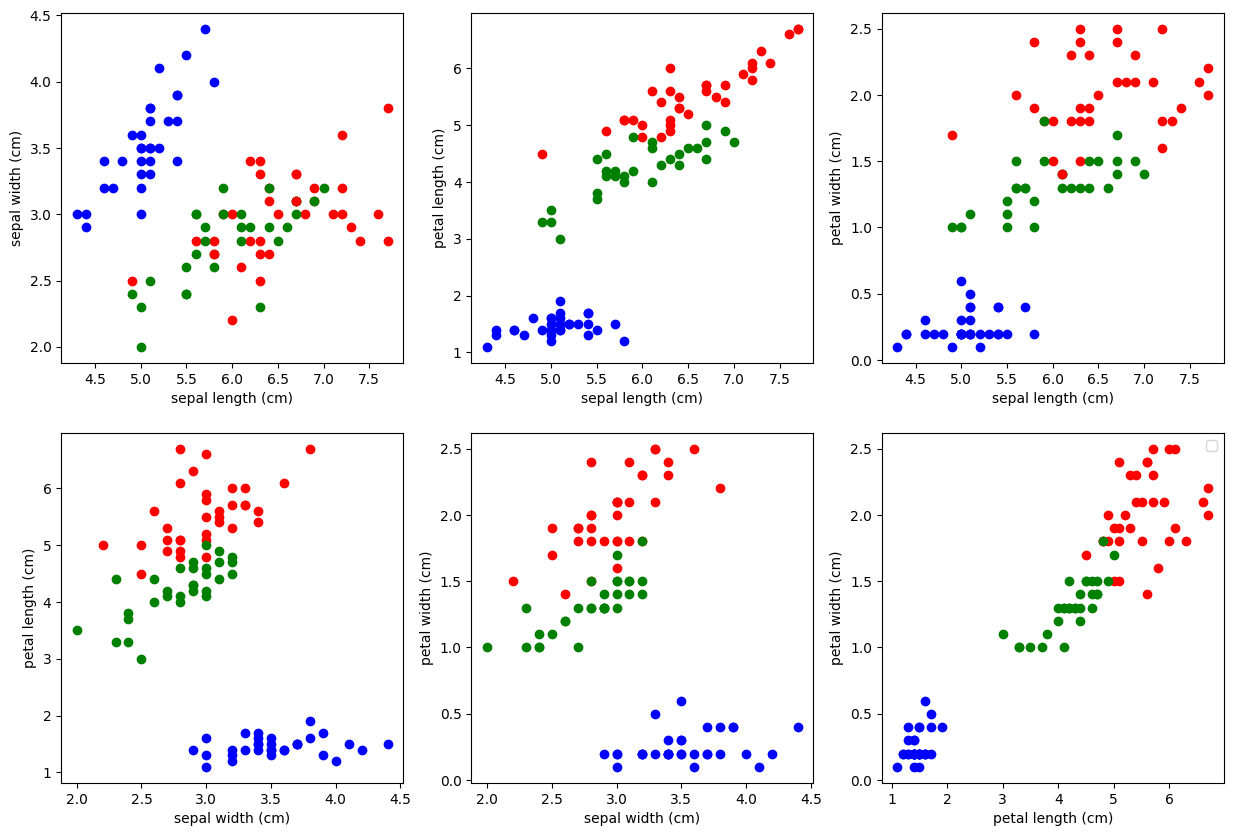

In [6]:
label = {0: 'blue', 1: 'green', 2: 'red'}
# 6 pairs
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Non-scaled values
for ind, row in enumerate(X_train):
    axes[0, 0].scatter(row[0], row[1], color=label[Y_train[ind]])
    axes[0, 0].set_xlabel(iris.feature_names[0])
    axes[0, 0].set_ylabel(iris.feature_names[1])

    axes[0, 1].scatter(row[0], row[2], color=label[Y_train[ind]])
    axes[0, 1].set_xlabel(iris.feature_names[0])
    axes[0, 1].set_ylabel(iris.feature_names[2])

    axes[0, 2].scatter(row[0], row[3], color=label[Y_train[ind]])
    axes[0, 2].set_xlabel(iris.feature_names[0])
    axes[0, 2].set_ylabel(iris.feature_names[3])

    axes[1, 0].scatter(row[1], row[2], color=label[Y_train[ind]])
    axes[1, 0].set_xlabel(iris.feature_names[1])
    axes[1, 0].set_ylabel(iris.feature_names[2])

    axes[1, 1].scatter(row[1], row[3], color=label[Y_train[ind]])
    axes[1, 1].set_xlabel(iris.feature_names[1])
    axes[1, 1].set_ylabel(iris.feature_names[3])

    axes[1, 2].scatter(row[2], row[3], color=label[Y_train[ind]])
    axes[1, 2].set_xlabel(iris.feature_names[2])
    axes[1, 2].set_ylabel(iris.feature_names[3])
plt.legend()
plt.show()

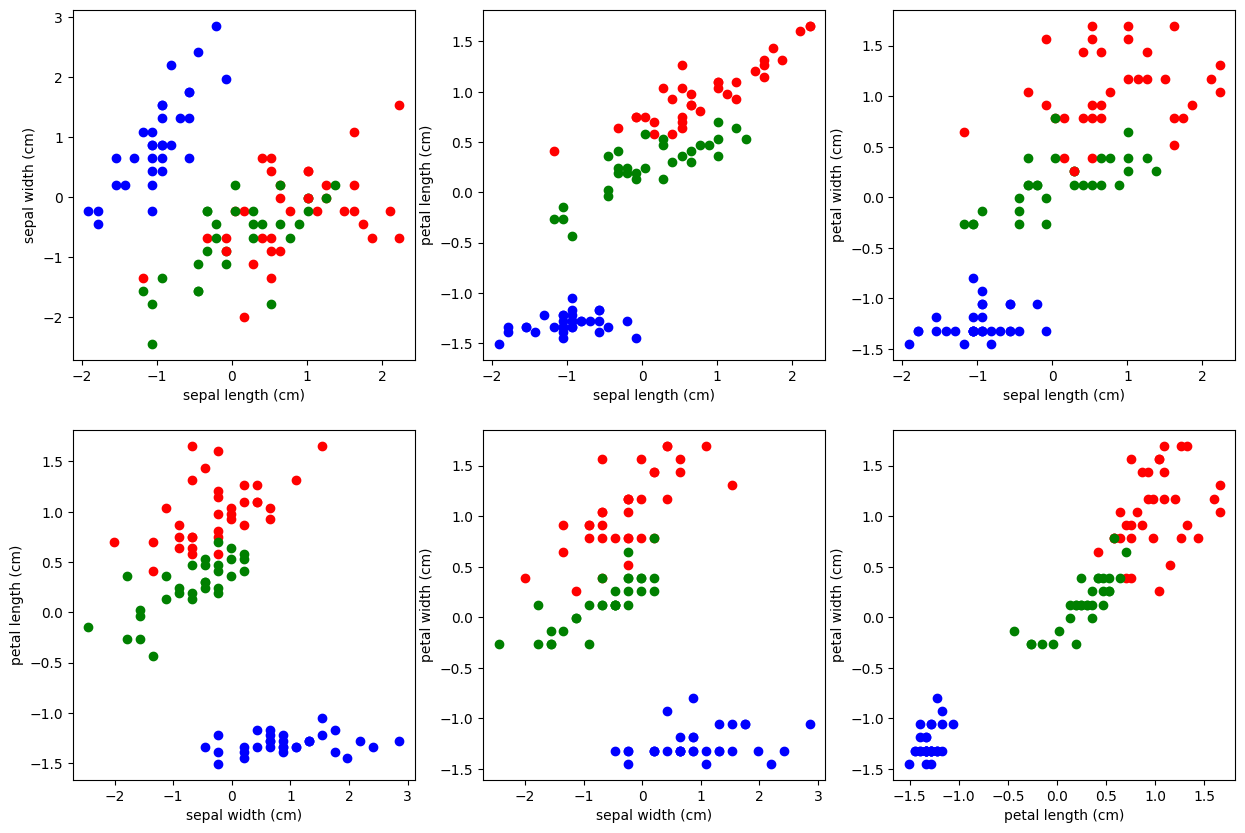

In [8]:
std_scaler = StandardScaler()
X_scaled = std_scaler.fit_transform(X_train)
label = {0: 'blue', 1: 'green', 2: 'red'}
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ind, row in enumerate(X_scaled):
    axes[0, 0].scatter(row[0], row[1], color=label[Y_train[ind]])
    axes[0, 0].set_xlabel(iris.feature_names[0])
    axes[0, 0].set_ylabel(iris.feature_names[1])

    axes[0, 1].scatter(row[0], row[2], color=label[Y_train[ind]])
    axes[0, 1].set_xlabel(iris.feature_names[0])
    axes[0, 1].set_ylabel(iris.feature_names[2])

    axes[0, 2].scatter(row[0], row[3], color=label[Y_train[ind]])
    axes[0, 2].set_xlabel(iris.feature_names[0])
    axes[0, 2].set_ylabel(iris.feature_names[3])

    axes[1, 0].scatter(row[1], row[2], color=label[Y_train[ind]])
    axes[1, 0].set_xlabel(iris.feature_names[1])
    axes[1, 0].set_ylabel(iris.feature_names[2])

    axes[1, 1].scatter(row[1], row[3], color=label[Y_train[ind]])
    axes[1, 1].set_xlabel(iris.feature_names[1])
    axes[1, 1].set_ylabel(iris.feature_names[3])

    axes[1, 2].scatter(row[2], row[3], color=label[Y_train[ind]])
    axes[1, 2].set_xlabel(iris.feature_names[2])
    axes[1, 2].set_ylabel(iris.feature_names[3])
plt.draw()
plt.show()

Notice class 0 is linearly separable from the rest (both 1 and 2) ==> we can train an SVM to detect class 0

In [9]:
X_train[:5]

array([[6. , 3. , 4.8, 1.8],
       [6.7, 3.1, 4.7, 1.5],
       [5.5, 2.4, 3.7, 1. ],
       [5.4, 3.4, 1.7, 0.2],
       [6.8, 3. , 5.5, 2.1]])

In [10]:
X_scaled[:5]

array([[ 0.16110746, -0.23717928,  0.58382847,  0.77996804],
       [ 1.01358158, -0.01611898,  0.52732894,  0.3865691 ],
       [-0.44780262, -1.56354107, -0.03766635, -0.2690958 ],
       [-0.56958464,  0.64706191, -1.16765695, -1.31815965],
       [ 1.1353636 , -0.23717928,  0.97932518,  1.17336698]])

X 

In [29]:
# C = 1
svm_clf = LinearSVC(C=2, loss="hinge")
svm_clf.fit(X_train, Y_train)

f:\University\MASc - Concordia\Algorithms\.venv\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(C=2, loss='hinge')

In [30]:
svm_prediction = svm_clf.predict(X_validate)
svm_prediction == Y_validate

array([ True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True, False, False,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True])